# Reproject the ESA-CCI land cover map for Europe

We use the ESA CCI Land Cover dataset provided through the [DeepESDL](https://www.earthsystemdatalab.net/) public S3 bucket.

In the following cell, we open the multi-resolution dataset `"LC-1x2025x2025-2.0.0.levels"` and select its base level. The base level represents the native spatial resolution of the product, which is approximately 300 m.

For more information on working with multi-resolution datasets in xcube, see the [xcube multi-resolution datasets documentation](https://xcube.readthedocs.io/en/latest/mldatasets.html).


In [1]:
from xcube.core.store import new_data_store
from xcube_resampling.spatial import resample_in_space
from xcube_resampling.gridmapping import GridMapping
from datetime import datetime
import matplotlib.pyplot as plt
import pyproj
import numpy as np

In [2]:
%%time
store = new_data_store("s3", root="deep-esdl-public")
mlds_lc = store.open_data("LC-1x2025x2025-2.0.0.levels")
ds = mlds_lc.base_dataset
ds_time_slice = ds.sel(time=datetime(2022, 1, 1))
ds

CPU times: user 245 ms, sys: 61.5 ms, total: 307 ms
Wall time: 1.33 s


<xarray.Dataset> Size: 3TB
Dimensions:              (time: 31, lat: 64800, lon: 129600, bounds: 2)
Coordinates:
  * time                 (time) datetime64[ns] 248B 1992-01-01 ... 2022-01-01
  * lat                  (lat) float64 518kB 90.0 90.0 89.99 ... -90.0 -90.0
  * lon                  (lon) float64 1MB -180.0 -180.0 -180.0 ... 180.0 180.0
Dimensions without coordinates: bounds
Data variables:
    change_count         (time, lat, lon) uint8 260GB dask.array<chunksize=(1, 2025, 2025), meta=np.ndarray>
    crs                  int32 4B ...
    current_pixel_state  (time, lat, lon) float32 1TB dask.array<chunksize=(1, 2025, 2025), meta=np.ndarray>
    lat_bounds           (lat, bounds) float64 1MB dask.array<chunksize=(2025, 2), meta=np.ndarray>
    lccs_class           (time, lat, lon) uint8 260GB dask.array<chunksize=(1, 2025, 2025), meta=np.ndarray>
    lon_bounds           (lon, bounds) float64 2MB dask.array<chunksize=(2025, 2), meta=np.ndarray>
    observation_count    (time, lat, lon) uint16 521GB dask.array<chunksize=(1, 2025, 2025), meta=np.ndarray>
    processed_flag       (time, lat, lon) float32 1TB dask.array<chunksize=(1, 2025, 2025), meta=np.ndarray>
    time_bounds          (time, bounds) datetime64[ns] 496B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    https://www.ecmwf.int/en/about/contact-us/get...
    creation_date:              20181130T095451Z
    ...                         ...
    time_coverage_end:          19921231
    time_coverage_resolution:   P1Y
    time_coverage_start:        19920101
    title:                      Land Cover Map of ESA CCI brokered by CDS
    tracking_id:                61b96fd7-42c3-4374-9de1-0dc3b0bcae2a
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y

First, we generate a regular grid mapping covering Germany in the **LAEA** projection (EPSG:3035). This grid will serve as the **target grid mapping** for subsequent resampling and reprojection operations.

In [3]:
%%time
bbox = [5, 46, 15, 57]
target_crs = "EPSG:3035"
t = pyproj.Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
target_bbox = t.transform_bounds(*bbox)
spatial_res = 150
x_size = int((target_bbox[2] - target_bbox[0]) / spatial_res) + 1
y_size = int(abs(target_bbox[3] - target_bbox[1]) / spatial_res) + 1
target_gm = GridMapping.regular(
    size=(x_size, y_size),
    xy_min=(target_bbox[0] - spatial_res / 2, target_bbox[1] - spatial_res / 2),
    xy_res=spatial_res,
    crs=target_crs,
    tile_size=4000,
)

CPU times: user 32.5 ms, sys: 6.64 ms, total: 39.1 ms
Wall time: 54.9 ms


Next, we apply the [`resample_in_space`](https://xcube-dev.github.io/xcube-resampling/guide/#spatial-resampling-algorithms) method, providing the source dataset and the target grid mapping.

Although both the source dataset and the target grid are regular, they use different coordinate reference systems (CRS). As a result, `resample_in_space` internally calls `reproject_dataset` to handle the reprojection.

The `reproject_dataset` method is capable of processing source datasets of any size. It automatically identifies the overlapping portions of the source dataset that intersect with the target grid mapping, ensuring that only relevant data is reprojected.

In [4]:
%%time
ds_resampling = resample_in_space(ds_time_slice, target_gm=target_gm)
ds_resampling

CPU times: user 12.4 s, sys: 375 ms, total: 12.7 s
Wall time: 11.7 s


<xarray.Dataset> Size: 510MB
Dimensions:              (x: 5167, y: 8227, bounds: 2)
Coordinates:
  * x                    (x) float64 41kB 3.933e+06 3.934e+06 ... 4.708e+06
  * y                    (y) float64 66kB 3.777e+06 3.777e+06 ... 2.543e+06
    time                 datetime64[ns] 8B 2022-01-01
    spatial_ref          int64 8B 0
Dimensions without coordinates: bounds
Data variables:
    change_count         (y, x) uint8 43MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>
    current_pixel_state  (y, x) float32 170MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>
    lccs_class           (y, x) uint8 43MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>
    observation_count    (y, x) uint16 85MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>
    processed_flag       (y, x) float32 170MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>
    time_bounds          (bounds) datetime64[ns] 16B dask.array<chunksize=(2,), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    https://www.ecmwf.int/en/about/contact-us/get...
    creation_date:              20181130T095451Z
    ...                         ...
    time_coverage_end:          19921231
    time_coverage_resolution:   P1Y
    time_coverage_start:        19920101
    title:                      Land Cover Map of ESA CCI brokered by CDS
    tracking_id:                61b96fd7-42c3-4374-9de1-0dc3b0bcae2a
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y

CPU times: user 7.05 s, sys: 912 ms, total: 7.96 s
Wall time: 3.52 s


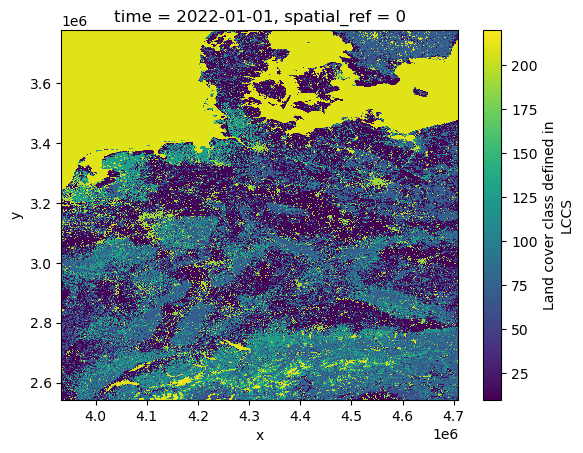

In [5]:
%%time
ds_resampling.lccs_class[::5, ::5].plot()

Next, we demonstrate that the `resample_in_space` method can also handle **3D data arrays** by selecting multiple years from the dataset.

In [6]:
%%time
ds = ds.sel(time=slice(datetime(2018, 1, 1), datetime(2022, 1, 1)))
ds = ds[["lccs_class"]]
ds

CPU times: user 49.6 ms, sys: 9.05 ms, total: 58.7 ms
Wall time: 57.7 ms


<xarray.Dataset> Size: 42GB
Dimensions:     (time: 5, lat: 64800, lon: 129600)
Coordinates:
  * time        (time) datetime64[ns] 40B 2018-01-01 2019-01-01 ... 2022-01-01
  * lat         (lat) float64 518kB 90.0 90.0 89.99 89.99 ... -89.99 -90.0 -90.0
  * lon         (lon) float64 1MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
Data variables:
    lccs_class  (time, lat, lon) uint8 42GB dask.array<chunksize=(1, 2025, 2025), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    https://www.ecmwf.int/en/about/contact-us/get...
    creation_date:              20181130T095451Z
    ...                         ...
    time_coverage_end:          19921231
    time_coverage_resolution:   P1Y
    time_coverage_start:        19920101
    title:                      Land Cover Map of ESA CCI brokered by CDS
    tracking_id:                61b96fd7-42c3-4374-9de1-0dc3b0bcae2a
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y

In [7]:
%%time
bbox = [-20, 25, 40, 85]
target_crs = "EPSG:3035"
t = pyproj.Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
target_bbox = t.transform_bounds(*bbox)
spatial_res = 300
x_size = int((target_bbox[2] - target_bbox[0]) / spatial_res) + 1
y_size = int(abs(target_bbox[3] - target_bbox[1]) / spatial_res) + 1
target_gm = GridMapping.regular(
    size=(x_size, y_size),
    xy_min=(target_bbox[0] - spatial_res / 2, target_bbox[1] - spatial_res / 2),
    xy_res=spatial_res,
    crs=target_crs,
    tile_size=4000,
)
target_gm

CPU times: user 22 ms, sys: 2.01 ms, total: 24 ms
Wall time: 23.1 ms


class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:3035
* xy_res: (300, 300)
* xy_bbox: (1287377.0, 239252.0, 7354277.0, 6906752.0)
* ij_bbox: (0, 0, 20223, 22225)
* xy_dim_names: ('x', 'y')
* xy_var_names: ('x', 'y')
* size: (20223, 22225)
* tile_size: (4000, 4000)

In [8]:
%%time
ds_reproject = resample_in_space(ds, target_gm=target_gm)
ds_reproject

CPU times: user 30.3 s, sys: 321 ms, total: 30.6 s
Wall time: 29.1 s


<xarray.Dataset> Size: 2GB
Dimensions:      (time: 5, x: 20223, y: 22225)
Coordinates:
  * time         (time) datetime64[ns] 40B 2018-01-01 2019-01-01 ... 2022-01-01
  * x            (x) float64 162kB 1.288e+06 1.288e+06 ... 7.354e+06 7.354e+06
  * y            (y) float64 178kB 6.907e+06 6.906e+06 ... 2.397e+05 2.394e+05
    spatial_ref  int64 8B 0
Data variables:
    lccs_class   (time, y, x) uint8 2GB dask.array<chunksize=(1, 4000, 4000), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    https://www.ecmwf.int/en/about/contact-us/get...
    creation_date:              20181130T095451Z
    ...                         ...
    time_coverage_end:          19921231
    time_coverage_resolution:   P1Y
    time_coverage_start:        19920101
    title:                      Land Cover Map of ESA CCI brokered by CDS
    tracking_id:                61b96fd7-42c3-4374-9de1-0dc3b0bcae2a
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y

CPU times: user 2min 18s, sys: 25.9 s, total: 2min 44s
Wall time: 57.1 s


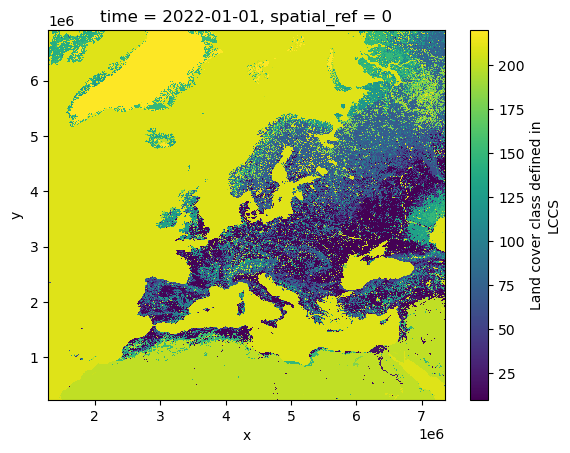

In [9]:
%%time
ds_reproject.lccs_class.isel(time=-1)[::20, ::20].plot()

We can also clip the dataset before resampling. In this case, areas outside the clipping region will be filled with **fill values**.  

These fill values can be specified by the user for each data variable using the `fill_values` parameter. If no fill value is provided, a default is derived automatically based on the data type of each array.

In [10]:
%%time
ds_clip = ds.sel(lon=slice(-20, 40), lat=slice(85, 25))
ds_clip_reproject = resample_in_space(ds_clip, target_gm=target_gm)
ds_clip_reproject

CPU times: user 14.8 s, sys: 221 ms, total: 15 s
Wall time: 13.5 s


<xarray.Dataset> Size: 2GB
Dimensions:      (time: 5, x: 20223, y: 22225)
Coordinates:
  * time         (time) datetime64[ns] 40B 2018-01-01 2019-01-01 ... 2022-01-01
  * x            (x) float64 162kB 1.288e+06 1.288e+06 ... 7.354e+06 7.354e+06
  * y            (y) float64 178kB 6.907e+06 6.906e+06 ... 2.397e+05 2.394e+05
    spatial_ref  int64 8B 0
Data variables:
    lccs_class   (time, y, x) uint8 2GB dask.array<chunksize=(1, 4000, 4000), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    https://www.ecmwf.int/en/about/contact-us/get...
    creation_date:              20181130T095451Z
    ...                         ...
    time_coverage_end:          19921231
    time_coverage_resolution:   P1Y
    time_coverage_start:        19920101
    title:                      Land Cover Map of ESA CCI brokered by CDS
    tracking_id:                61b96fd7-42c3-4374-9de1-0dc3b0bcae2a
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y

CPU times: user 3min 20s, sys: 1min 14s, total: 4min 34s
Wall time: 29.8 s


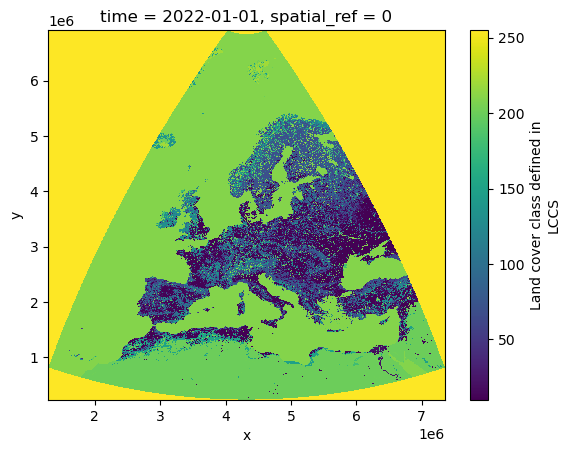

In [11]:
%%time
ds_clip_reproject.lccs_class.isel(time=-1)[::20, ::20].plot()